In [ ]:
!pip install -U tensorflow_datasets tensorflow
!pip install -U importlib_resources


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompati

In [ ]:



import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gc

from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 224
NUM_CLASSES = 37
BATCH_SIZE = 32
EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE

# Increase these values if GPU memory/runtime permits
TRAIN_SIZE = 2500
VAL_SIZE = 500
TEST_SIZE = 500


In [ ]:
(train_full, test_full), info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(info)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
       

In [ ]:
train_raw = train_full.take(TRAIN_SIZE)
val_raw = test_full.take(VAL_SIZE)
final_test_raw = test_full.skip(VAL_SIZE).take(TEST_SIZE)

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def create_dataset(dataset, batch_size=BATCH_SIZE, shuffle=False):
    if shuffle:
        dataset = dataset.shuffle(1000, seed=SEED)

    return (
        dataset
        .map(preprocess, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

train_ds = create_dataset(train_raw, shuffle=True)
val_ds = create_dataset(val_raw)
test_ds = create_dataset(final_test_raw)


In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
from google.colab import files
def save_plot(filename):

    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")

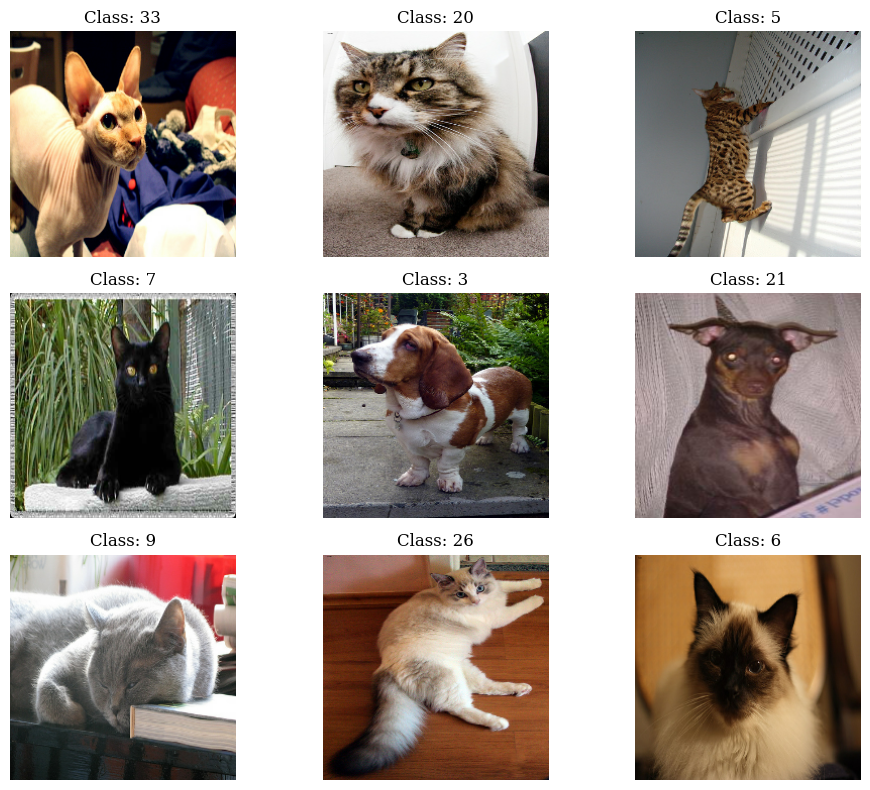

In [ ]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        image = (images[i].numpy() + 1) / 2
        plt.imshow(image)
        plt.title(f"Class: {labels[i].numpy()}")
        plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
def create_model(
    dropout_rate=0.0,
    l2_reg=0.0,
    batch_norm=False,
    initializer="glorot_uniform",
    trainable_base=False,
    optimizer="adam",
    learning_rate=0.001
):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = trainable_base

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    if batch_norm:
        x = layers.BatchNormalization()(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)

    model = tf.keras.Model(inputs, outputs)

    if optimizer == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "momentum":
        opt = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )
    elif optimizer == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [ ]:
initializers = {
    "Zero": "zeros",
    "Random": tf.keras.initializers.RandomNormal(stddev=0.05),
    "Xavier": "glorot_uniform",
    "He": "he_normal"
}

init_histories = {}

for name, initializer in initializers.items():
    print(f"Training with {name} initialization")

    tf.keras.backend.clear_session()

    model = create_model(
        initializer=initializer,
        optimizer="adam",
        learning_rate=0.001
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    init_histories[name] = history.history

    del model
    gc.collect()


Training with Zero initialization
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7516 - loss: 1.2779 - val_accuracy: 0.8720 - val_loss: 0.4988
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9472 - loss: 0.3012 - val_accuracy: 0.8800 - val_loss: 0.3880
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9660 - loss: 0.1929 - val_accuracy: 0.9040 - val_loss: 0.3477
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9768 - loss: 0.1352 - val_accuracy: 0.8920 - val_loss: 0.3337
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9912 - loss: 0.1015 - val_accuracy: 0.8940 - val_loss: 0.3281
Training with Random initialization
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6300 - loss: 1.4900 - val_accuracy: 0.8520 - val_loss: 0.5971
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9156 - loss: 0.3556 - val_accuracy: 0.8780 - val_loss: 0.4360

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: loss_epoch.eps


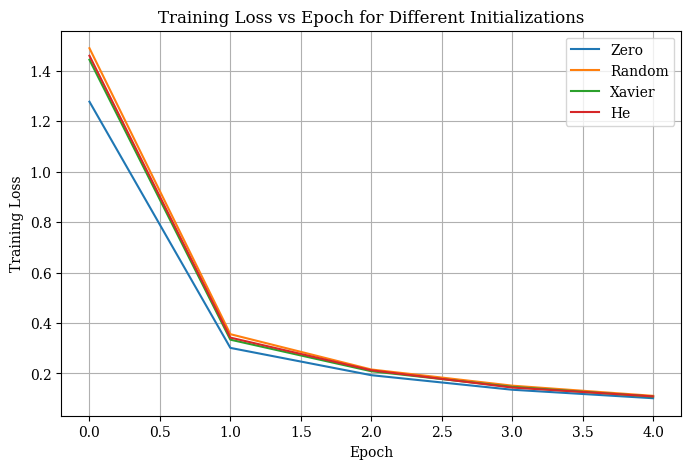

In [ ]:
plt.figure(figsize=(8, 5))

for name, history in init_histories.items():
    plt.plot(history["loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch for Different Initializations")
plt.legend()
plt.grid()
save_plot("loss_epoch")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: accuracy_epoch.eps


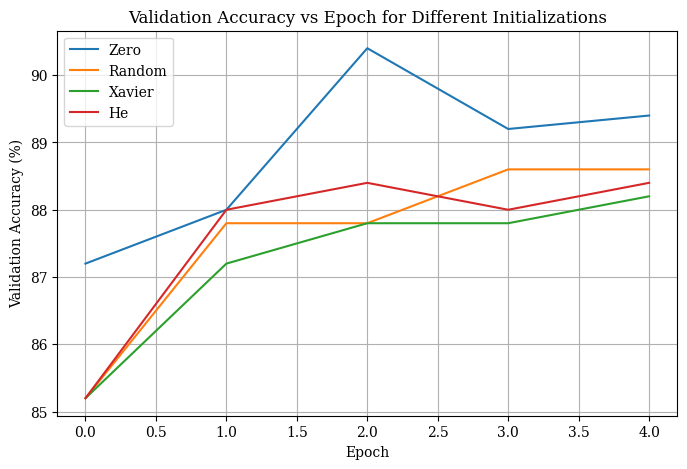

In [ ]:
plt.figure(figsize=(8, 5))

for name, history in init_histories.items():
    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Epoch for Different Initializations")
plt.legend()
plt.grid()
save_plot("accuracy_epoch")
plt.show()


In [ ]:
regularization_configs = {
    "No Regularization": {
        "dropout_rate": 0.0,
        "l2_reg": 0.0,
        "batch_norm": False
    },
    "L2": {
        "dropout_rate": 0.0,
        "l2_reg": 0.001,
        "batch_norm": False
    },
    "Dropout": {
        "dropout_rate": 0.5,
        "l2_reg": 0.0,
        "batch_norm": False
    },
    "BatchNorm": {
        "dropout_rate": 0.0,
        "l2_reg": 0.0,
        "batch_norm": True
    }
}

reg_histories = {}

for name, config in regularization_configs.items():
    print(f"Training: {name}")

    tf.keras.backend.clear_session()

    model = create_model(**config)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    reg_histories[name] = history.history

    del model
    gc.collect()


Training: No Regularization
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.6600 - loss: 1.4143 - val_accuracy: 0.8440 - val_loss: 0.5772
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9248 - loss: 0.3397 - val_accuracy: 0.8740 - val_loss: 0.4440
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9572 - loss: 0.2162 - val_accuracy: 0.8940 - val_loss: 0.3827
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9716 - loss: 0.1487 - val_accuracy: 0.8880 - val_loss: 0.3526
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9860 - loss: 0.1076 - val_accuracy: 0.8900 - val_loss: 0.3421
Training: L2
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.6456 - loss: 1.5110 - val_accuracy: 0.8640 - val_loss: 0.6610
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9224 - loss: 0.4430 - val_accuracy: 0.8800 - val_loss: 0.5262
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9592 - loss: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: reg.eps


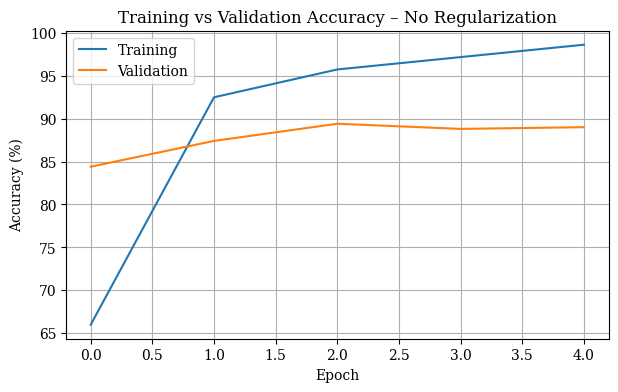

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: reg.eps


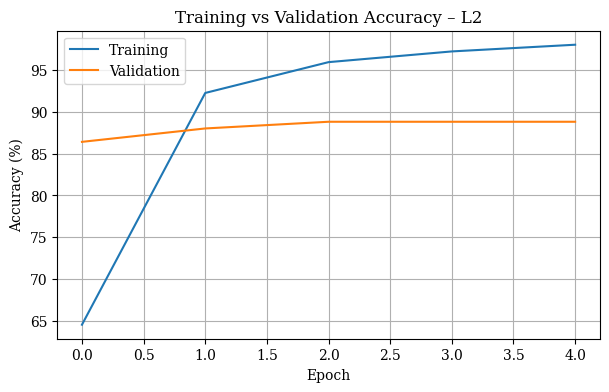

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: reg.eps


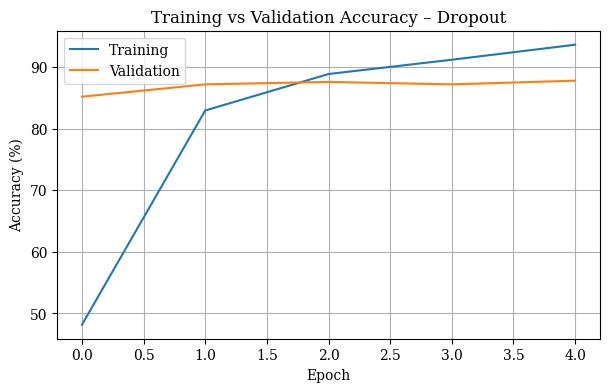

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: reg.eps


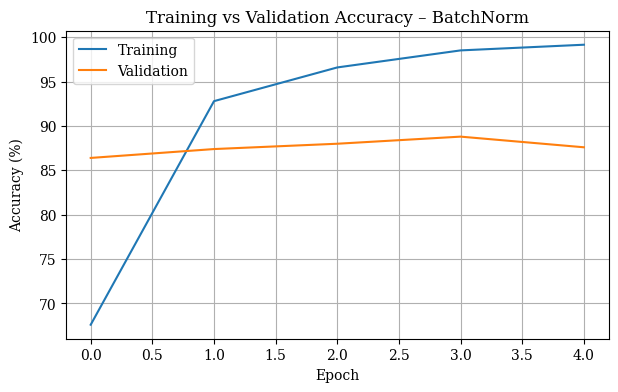

In [ ]:
for name, history in reg_histories.items():
    plt.figure(figsize=(7, 4))

    plt.plot(np.array(history["accuracy"]) * 100, label="Training")
    plt.plot(np.array(history["val_accuracy"]) * 100, label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Training vs Validation Accuracy – {name}")
    plt.legend()
    plt.grid()
    save_plot("reg")
    plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: no_reg.eps


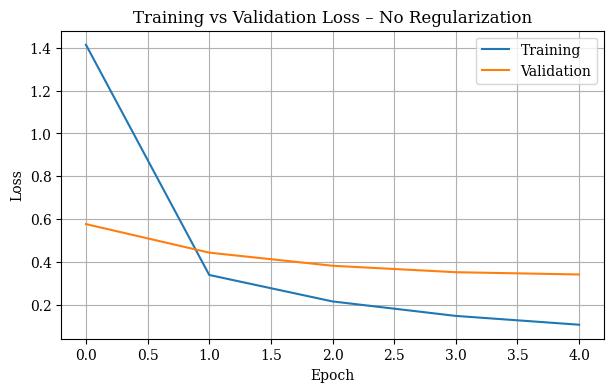

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: no_reg.eps


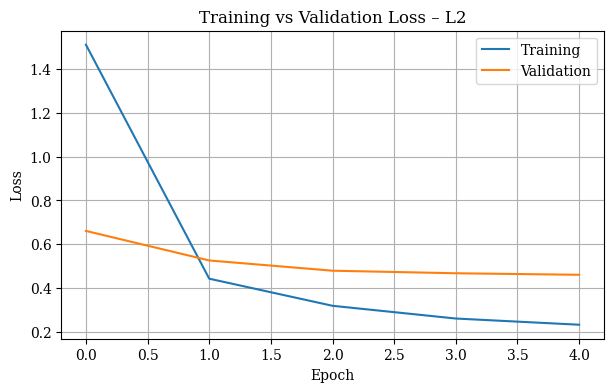

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: no_reg.eps


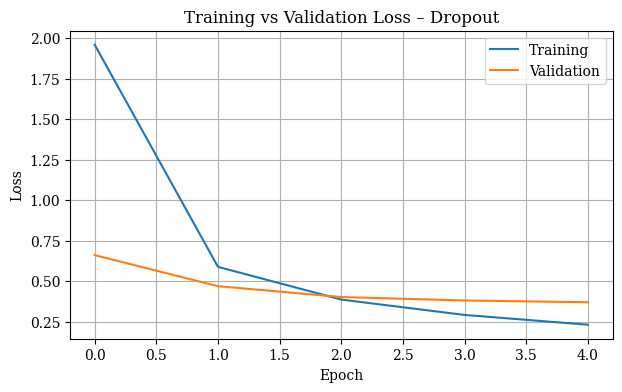

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: no_reg.eps


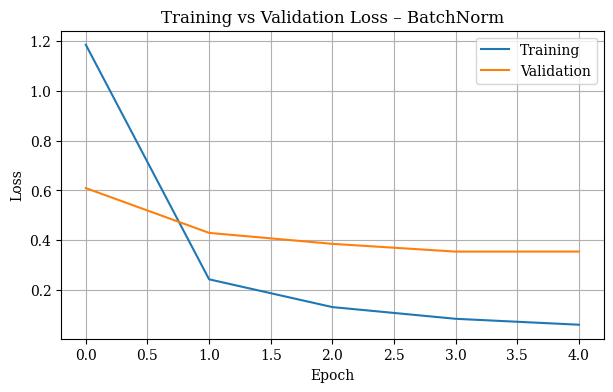

In [ ]:
for name, history in reg_histories.items():
    plt.figure(figsize=(7, 4))

    plt.plot(history["loss"], label="Training")
    plt.plot(history["val_loss"], label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs Validation Loss – {name}")
    plt.legend()
    plt.grid()
    save_plot("no_reg")
    plt.show()


In [ ]:
bn_histories = {}

for use_bn in [False, True]:
    name = "With BatchNorm" if use_bn else "Without BatchNorm"

    tf.keras.backend.clear_session()

    model = create_model(batch_norm=use_bn)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    bn_histories[name] = history.history

    del model
    gc.collect()


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.6468 - loss: 1.4501 - val_accuracy: 0.8580 - val_loss: 0.5749
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9216 - loss: 0.3436 - val_accuracy: 0.8740 - val_loss: 0.4397
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9528 - loss: 0.2149 - val_accuracy: 0.8780 - val_loss: 0.3980
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9716 - loss: 0.1519 - val_accuracy: 0.8860 - val_loss: 0.3780
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9864 - loss: 0.1116 - val_accuracy: 0.8920 - val_loss: 0.3533
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6856 - loss: 1.1807 - val_accuracy: 0.8180 - val_loss: 0.6661
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9340 - loss: 0.2367 - val_accuracy: 0.8580 - val_loss: 0.4410
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9712 - loss: 0.1224 - val_accuracy: 0.8720 - val_loss:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: batch_norm.eps


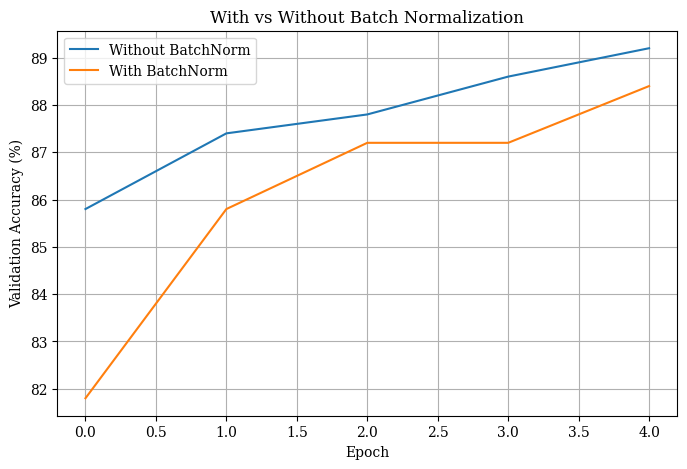

In [ ]:
plt.figure(figsize=(8, 5))

for name, history in bn_histories.items():
    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("With vs Without Batch Normalization")
plt.legend()
plt.grid()
save_plot("batch_norm")
plt.show()


In [ ]:
optimizers = ["sgd", "momentum", "rmsprop", "adam"]

optimizer_histories = {}
optimizer_results = []

for opt_name in optimizers:
    print(f"Training with {opt_name}")

    tf.keras.backend.clear_session()

    model = create_model(
        optimizer=opt_name,
        learning_rate=0.001
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    elapsed_time = time.time() - start_time

    optimizer_histories[opt_name] = history.history

    optimizer_results.append({
        "Optimizer": opt_name,
        "Final Loss": history.history["loss"][-1],
        "Best Validation Accuracy (%)": max(history.history["val_accuracy"]) * 100,
        "Training Time (s)": elapsed_time
    })

    del model
    gc.collect()

optimizer_df = pd.DataFrame(optimizer_results)
optimizer_df


Training with sgd
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.0456 - loss: 3.6862 - val_accuracy: 0.0660 - val_loss: 3.6207
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.0892 - loss: 3.4221 - val_accuracy: 0.1120 - val_loss: 3.3801
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.1516 - loss: 3.1848 - val_accuracy: 0.1780 - val_loss: 3.1615
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.2320 - loss: 2.9669 - val_accuracy: 0.2360 - val_loss: 2.9590
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.3236 - loss: 2.7655 - val_accuracy: 0.2940 - val_loss: 2.7700
Training with momentum
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.2172 - loss: 3.1152 - val_accuracy: 0.5280 - val_loss: 2.2154
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7208 - loss: 1.5975 - val_accuracy: 0.7540 - val_loss: 1.2624
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8472 - loss: 

,Optimizer,Final Loss,Best Validation Accuracy (%),Training Time (s)
0,sgd,2.765497,29.400000,636.085381
1,momentum,0.560220,85.000002,653.257763
2,rmsprop,0.084906,89.800000,588.517508
3,adam,0.108210,88.000000,652.525496


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: optimizers.eps


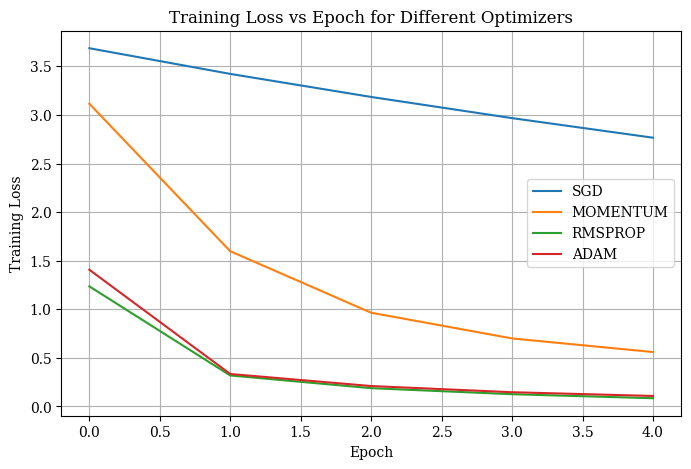

In [ ]:
plt.figure(figsize=(8, 5))

for name, history in optimizer_histories.items():
    plt.plot(history["loss"], label=name.upper())

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch for Different Optimizers")
plt.legend()
plt.grid()
save_plot("optimizers")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: acc_optimizers.eps


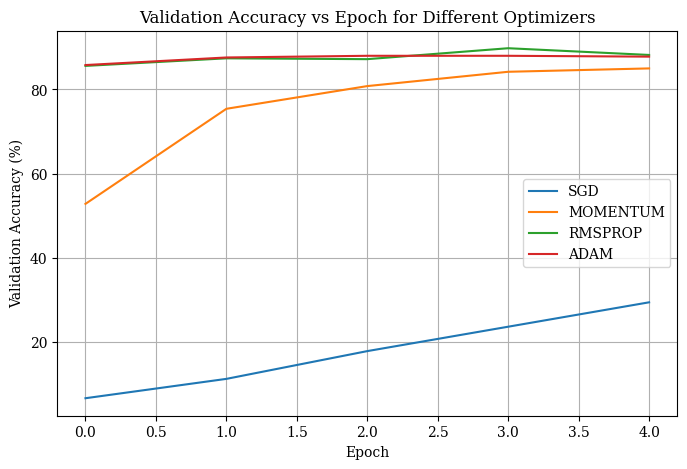

In [ ]:
plt.figure(figsize=(8, 5))

for name, history in optimizer_histories.items():
    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        label=name.upper()
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Epoch for Different Optimizers")
plt.legend()
plt.grid()
save_plot("acc_optimizers")
plt.show()


In [ ]:
learning_rates = [0.001, 0.0001]
lr_results = []

for lr in learning_rates:
    print(f"Learning rate: {lr}")

    tf.keras.backend.clear_session()

    model = create_model(
        optimizer="adam",
        learning_rate=lr
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=0
    )

    lr_results.append({
        "Learning Rate": lr,
        "Best Validation Accuracy (%)": max(history.history["val_accuracy"]) * 100
    })

    del model
    gc.collect()

lr_df = pd.DataFrame(lr_results)
lr_df


Learning rate: 0.001
Learning rate: 0.0001


,Learning Rate,Best Validation Accuracy (%)
0,0.0010,89.800000
1,0.0001,80.400002


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: lr_val_acc.eps


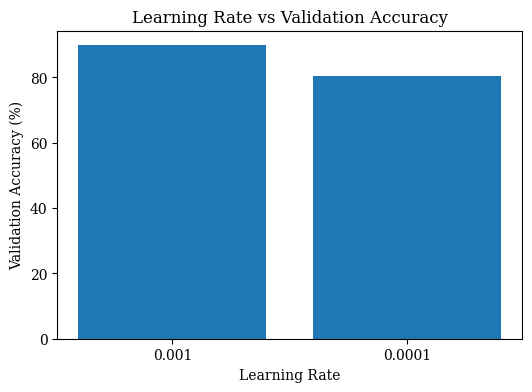

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(lr_df["Learning Rate"].astype(str), lr_df["Best Validation Accuracy (%)"])
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate vs Validation Accuracy")
save_plot("lr_val_acc")
plt.show()


In [ ]:
batch_sizes = [16, 32, 64]
batch_results = []

for batch_size in batch_sizes:
    print(f"Batch size: {batch_size}")

    train_temp = create_dataset(train_raw, batch_size=batch_size, shuffle=True)
    val_temp = create_dataset(val_raw, batch_size=batch_size)

    tf.keras.backend.clear_session()

    model = create_model()

    history = model.fit(
        train_temp,
        validation_data=val_temp,
        epochs=EPOCHS,
        verbose=0
    )

    batch_results.append({
        "Batch Size": batch_size,
        "Best Validation Accuracy (%)": max(history.history["val_accuracy"]) * 100
    })

    del model
    gc.collect()

batch_df = pd.DataFrame(batch_results)
batch_df


Batch size: 16
Batch size: 32
Batch size: 64


,Batch Size,Best Validation Accuracy (%)
0,16,88.999999
1,32,89.200002
2,64,88.800001


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: bsize_val_acc.eps


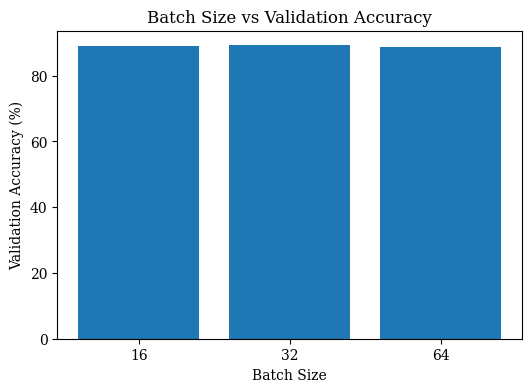

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(batch_df["Batch Size"].astype(str), batch_df["Best Validation Accuracy (%)"])
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Size vs Validation Accuracy")
save_plot("bsize_val_acc")
plt.show()


In [ ]:
dropout_rates = [0.0, 0.25, 0.5]
dropout_results = []

for dropout in dropout_rates:
    print(f"Dropout rate: {dropout}")

    tf.keras.backend.clear_session()

    model = create_model(dropout_rate=dropout)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=0
    )

    dropout_results.append({
        "Dropout Rate": dropout,
        "Best Validation Accuracy (%)": max(history.history["val_accuracy"]) * 100
    })

    del model
    gc.collect()

dropout_df = pd.DataFrame(dropout_results)
dropout_df


Dropout rate: 0.0
Dropout rate: 0.25
Dropout rate: 0.5


,Dropout Rate,Best Validation Accuracy (%)
0,0.00,88.800001
1,0.25,88.200003
2,0.50,89.399999


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: dropout_val_acc.eps


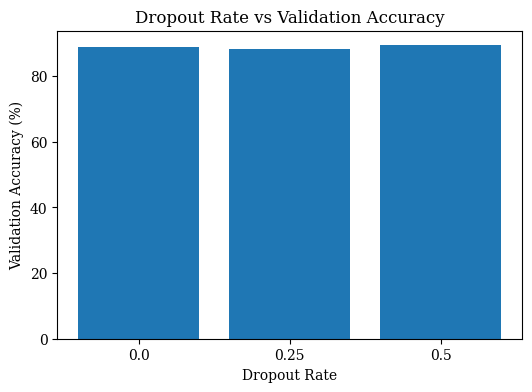

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(dropout_df["Dropout Rate"].astype(str), dropout_df["Best Validation Accuracy (%)"])
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Rate vs Validation Accuracy")
save_plot("dropout_val_acc")
plt.show()


In [ ]:
tf.keras.backend.clear_session()

feature_model = create_model(
    dropout_rate=0.25,
    optimizer="adam",
    learning_rate=0.001,
    trainable_base=False
)

feature_history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5824 - loss: 1.6621 - val_accuracy: 0.8560 - val_loss: 0.5854
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8928 - loss: 0.4295 - val_accuracy: 0.8780 - val_loss: 0.4247
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9352 - loss: 0.2648 - val_accuracy: 0.8820 - val_loss: 0.3726
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9580 - loss: 0.1961 - val_accuracy: 0.8860 - val_loss: 0.3359
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9676 - loss: 0.1495 - val_accuracy: 0.8820 - val_loss: 0.3311


In [ ]:
base_model = None

for layer in feature_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

base_model.trainable = True

FINE_TUNE_AT = 100

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

feature_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.8832 - loss: 0.4048 - val_accuracy: 0.8780 - val_loss: 0.3220
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9324 - loss: 0.2812 - val_accuracy: 0.8820 - val_loss: 0.3238
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.9416 - loss: 0.2258 - val_accuracy: 0.8900 - val_loss: 0.3243
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9576 - loss: 0.1999 - val_accuracy: 0.8980 - val_loss: 0.3275
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9612 - loss: 0.1773 - val_accuracy: 0.8940 - val_loss: 0.3270


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: feature_vs_fine_tune.eps


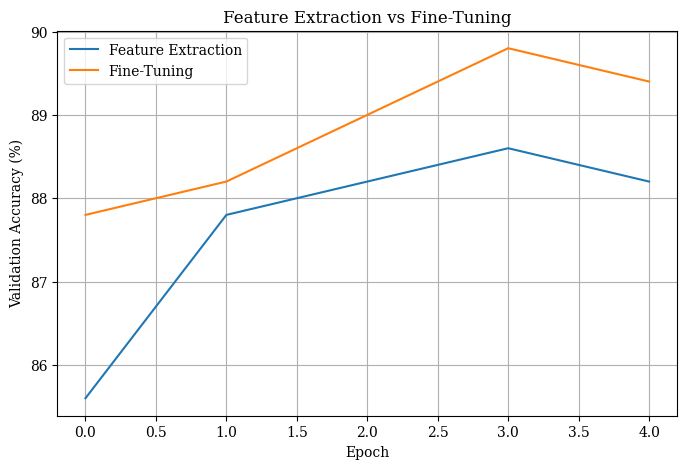

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(feature_history.history["val_accuracy"]) * 100,
    label="Feature Extraction"
)

plt.plot(
    np.array(fine_tune_history.history["val_accuracy"]) * 100,
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid()
save_plot("feature_vs_fine_tune")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: val_loss_finetune.eps


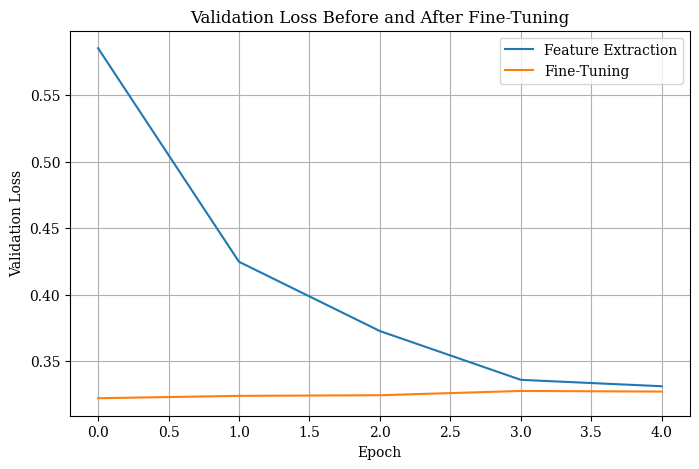

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(feature_history.history["val_loss"], label="Feature Extraction")
plt.plot(fine_tune_history.history["val_loss"], label="Fine-Tuning")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Before and After Fine-Tuning")
plt.legend()
plt.grid()
save_plot("val_loss_finetune")
plt.show()


In [ ]:
CV_SAMPLES = 1000

X_list = []
y_list = []

for image, label in train_raw.take(CV_SAMPLES):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)

    X_list.append(image.numpy())
    y_list.append(label.numpy())

X = np.array(X_list)
y = np.array(y_list)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1000, 224, 224, 3)
y shape: (1000,)


In [ ]:
configs = {
    "C1": {
        "dropout_rate": 0.0,
        "optimizer": "adam",
        "learning_rate": 0.001
    },
    "C2": {
        "dropout_rate": 0.25,
        "optimizer": "adam",
        "learning_rate": 0.001
    },
    "C3": {
        "dropout_rate": 0.5,
        "optimizer": "adam",
        "learning_rate": 0.0001
    }
}


In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_results = {}

for config_name, config in configs.items():
    print(f"Running cross-validation for {config_name}")

    fold_scores = []

    for fold, (train_index, val_index) in enumerate(kf.split(X)):
        print(f"Fold {fold + 1}/5")

        X_train = X[train_index]
        X_val = X[val_index]

        y_train = y[train_index]
        y_val = y[val_index]

        tf.keras.backend.clear_session()

        model = create_model(
            dropout_rate=config["dropout_rate"],
            optimizer=config["optimizer"],
            learning_rate=config["learning_rate"]
        )

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=3,
            batch_size=32,
            verbose=0
        )

        fold_scores.append(
            max(history.history["val_accuracy"])
        )

        del model
        gc.collect()

    cv_results[config_name] = fold_scores


Running cross-validation for C1
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Running cross-validation for C2
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Running cross-validation for C3
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


In [ ]:
cv_table = []

for config_name, scores in cv_results.items():
    cv_table.append({
        "Configuration": config_name,
        "F1": scores[0] * 100,
        "F2": scores[1] * 100,
        "F3": scores[2] * 100,
        "F4": scores[3] * 100,
        "F5": scores[4] * 100,
        "Mean Accuracy (%)": np.mean(scores) * 100,
        "SD (%)": np.std(scores) * 100
    })

cv_df = pd.DataFrame(cv_table)
cv_df


,Configuration,F1,F2,F3,F4,F5,Mean Accuracy (%),SD (%)
0,C1,85.000002,85.000002,87.0,88.499999,83.999997,85.900000,1.624808
1,C2,86.500001,83.499998,87.5,84.500003,80.000001,84.400001,2.615339
2,C3,25.999999,8.000000,16.0,14.500000,17.000000,16.300000,5.775811


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: cv_acc.eps


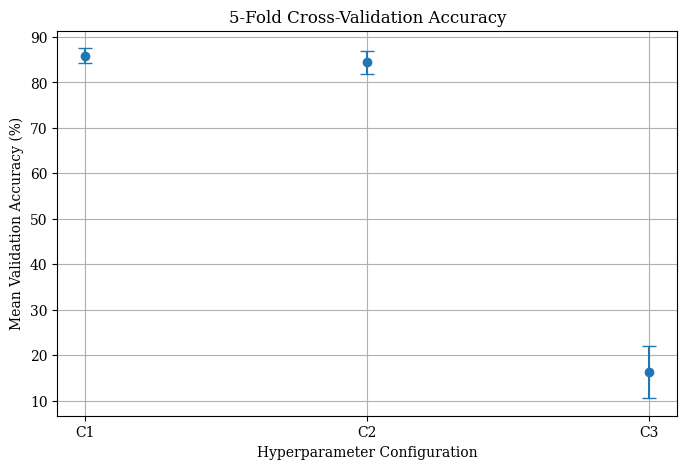

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    cv_df["Configuration"],
    cv_df["Mean Accuracy (%)"],
    yerr=cv_df["SD (%)"],
    fmt="o",
    capsize=5
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.grid()
save_plot("cv_acc")
plt.show()


In [ ]:
best_config_name = cv_df.loc[
    cv_df["Mean Accuracy (%)"].idxmax(),
    "Configuration"
]

best_config = configs[best_config_name]

print("Best configuration:", best_config_name)
print(best_config)


Best configuration: C1
{'dropout_rate': 0.0, 'optimizer': 'adam', 'learning_rate': 0.001}


In [ ]:
tf.keras.backend.clear_session()

final_model = create_model(
    dropout_rate=best_config["dropout_rate"],
    optimizer=best_config["optimizer"],
    learning_rate=best_config["learning_rate"]
)

start_time = time.time()

final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6612 - loss: 1.4056 - val_accuracy: 0.8440 - val_loss: 0.5728
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9204 - loss: 0.3426 - val_accuracy: 0.8800 - val_loss: 0.4434
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9560 - loss: 0.2121 - val_accuracy: 0.8800 - val_loss: 0.3699
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9740 - loss: 0.1481 - val_accuracy: 0.8960 - val_loss: 0.3529
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9880 - loss: 0.1122 - val_accuracy: 0.8800 - val_loss: 0.3486
Training time: 670.86 seconds


In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8900 - loss: 0.3834
Test Loss: 0.3834
Test Accuracy: 89.00%


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = final_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")


Accuracy : 89.00%
Precision: 90.22%
Recall   : 89.00%
F1 Score : 88.81%


In [ ]:
print("Number of parameters:", final_model.count_params())


Number of parameters: 2305381


In [ ]:
best_cv_row = cv_df[
    cv_df["Configuration"] == best_config_name
].iloc[0]

final_results = pd.DataFrame({
    "Metric": [
        "Mean CV Accuracy",
        "CV Standard Deviation",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (seconds)",
        "Number of Parameters"
    ],
    "Value": [
        f"{best_cv_row['Mean Accuracy (%)']:.2f}%",
        f"{best_cv_row['SD (%)']:.2f}%",
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{training_time:.2f}",
        final_model.count_params()
    ]
})

final_results


,Metric,Value
0,Mean CV Accuracy,85.90%
1,CV Standard Deviation,1.62%
2,Test Accuracy,89.00%
3,Precision,90.22%
4,Recall,89.00%
5,F1-score,88.81%
6,Training Time (seconds),670.86
7,Number of Parameters,2305381


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: confusion_matrix.eps


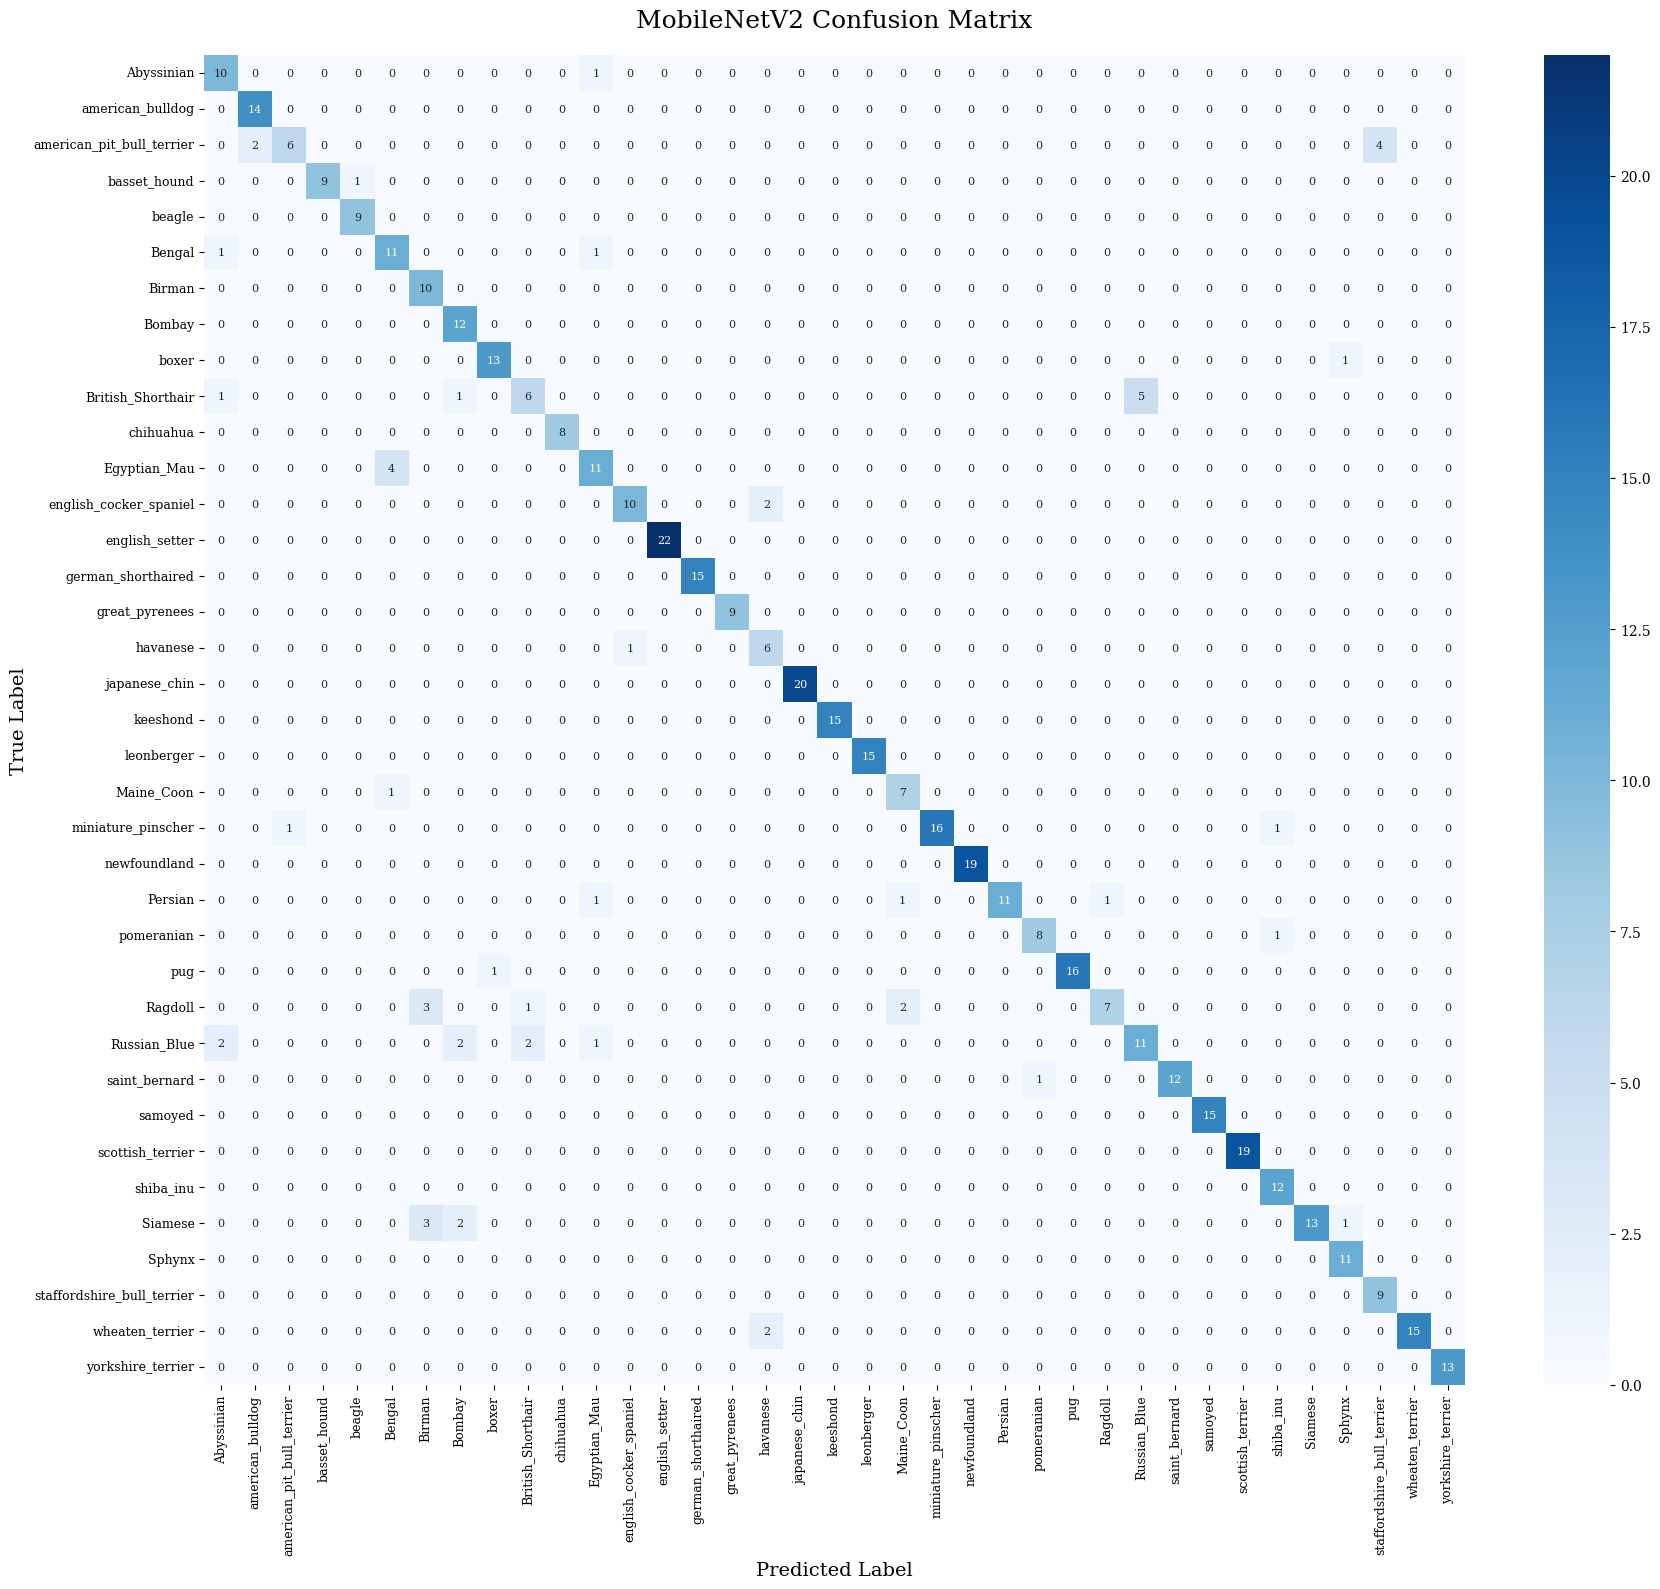

In [ ]:
# Confusion Matrix - Annotated Heatmap

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

# Get class names from the Oxford-IIIT Pet dataset
class_names = info.features["label"].names

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=True,          # Show numbers in each cell
    fmt="d",             # Integer format
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 8}
)

plt.title(
    "MobileNetV2 Confusion Matrix",
    fontsize=18,
    pad=20
)

plt.xlabel(
    "Predicted Label",
    fontsize=14
)

plt.ylabel(
    "True Label",
    fontsize=14
)

plt.xticks(
    rotation=90,
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

plt.tight_layout()
save_plot("confusion_matrix")
plt.show()

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import time, gc

from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# ---- same setup as your notebook ----
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 224
NUM_CLASSES = 37
BATCH_SIZE = 32
EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_SIZE = 2500
VAL_SIZE = 500
TEST_SIZE = 500

(train_full, test_full), info = tfds.load(
    "oxford_iiit_pet", split=["train", "test"], as_supervised=True, with_info=True
)

train_raw = train_full.take(TRAIN_SIZE)
val_raw = test_full.take(VAL_SIZE)
final_test_raw = test_full.skip(VAL_SIZE).take(TEST_SIZE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def create_dataset(dataset, batch_size=BATCH_SIZE, shuffle=False):
    if shuffle:
        dataset = dataset.shuffle(1000, seed=SEED)
    return (dataset.map(preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(batch_size).prefetch(AUTOTUNE))

train_ds = create_dataset(train_raw, shuffle=True)
val_ds = create_dataset(val_raw)
test_ds = create_dataset(final_test_raw)

def create_model(dropout_rate=0.0, l2_reg=0.0, batch_norm=False,
                  initializer="glorot_uniform", trainable_base=False,
                  optimizer="adam", learning_rate=0.001):
    base_model = MobileNetV2(include_top=False, weights="imagenet",
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = trainable_base
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                            kernel_initializer=initializer,
                            kernel_regularizer=regularizers.l2(l2_reg))(x)
    model = tf.keras.Model(inputs, outputs)
    if optimizer == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "momentum":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [ ]:
# ---- rebuild CV sample set exactly like cell 30 ----
CV_SAMPLES = 1000
X_list, y_list = [], []
for image, label in train_raw.take(CV_SAMPLES):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    X_list.append(image.numpy())
    y_list.append(label.numpy())
X = np.array(X_list)
y = np.array(y_list)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def run_cv(model_fn):
    """model_fn() -> compiled model. Returns fold scores list."""
    fold_scores = []
    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        tf.keras.backend.clear_session()
        model = model_fn()
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                             epochs=3, batch_size=32, verbose=0)
        fold_scores.append(max(history.history["val_accuracy"]))
        del model
        gc.collect()
    return fold_scores

def evaluate_on_test(model, ds):
    loss, acc = model.evaluate(ds, verbose=0)
    return acc


In [ ]:

results = {}

# ---------------- Best Initialization: Zero init ----------------
print("=== Best Initialization (Zero) ===")
scores = run_cv(lambda: create_model(initializer="zeros", optimizer="adam", learning_rate=0.001))
tf.keras.backend.clear_session()
model = create_model(initializer="zeros", optimizer="adam", learning_rate=0.001)
t0 = time.time()
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0)
train_time = time.time() - t0
test_acc = evaluate_on_test(model, test_ds)
results["Best Initialization"] = {
    "CV Accuracy": np.mean(scores) * 100,
    "SD": np.std(scores) * 100,
    "Test Accuracy": test_acc * 100,
    "Training Time": train_time
}
del model; gc.collect()

=== Best Initialization (Zero) ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


31425

In [ ]:

print("=== Best Optimizer (RMSprop) ===")
scores = run_cv(lambda: create_model(optimizer="rmsprop", learning_rate=0.001))
tf.keras.backend.clear_session()
model = create_model(optimizer="rmsprop", learning_rate=0.001)
t0 = time.time()
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0)
train_time = time.time() - t0
test_acc = evaluate_on_test(model, test_ds)
results["Best Optimizer"] = {
    "CV Accuracy": np.mean(scores) * 100,
    "SD": np.std(scores) * 100,
    "Test Accuracy": test_acc * 100,
    "Training Time": train_time
}
del model; gc.collect()

=== Best Optimizer (RMSprop) ===


31409

In [ ]:

print("=== Fine-Tuned Model ===")
def build_and_finetune():
    m = create_model(dropout_rate=0.25, optimizer="adam", learning_rate=0.001,
                      trainable_base=False)
    return m

def finetune_cv_fold(X_train, y_train, X_val, y_val):
    tf.keras.backend.clear_session()
    model = build_and_finetune()
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=2, batch_size=32, verbose=0)
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            break
    base_model.trainable = True
    FINE_TUNE_AT = 100
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=2, batch_size=32, verbose=0)
    acc = max(history.history["val_accuracy"])
    del model
    gc.collect()
    return acc

fold_scores = []
for train_index, val_index in kf.split(X):
    acc = finetune_cv_fold(X[train_index], y[train_index], X[val_index], y[val_index])
    fold_scores.append(acc)


=== Fine-Tuned Model ===


In [ ]:

t0 = time.time()
tf.keras.backend.clear_session()
ft_model = build_and_finetune()
ft_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0)
base_model = None
for layer in ft_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break
base_model.trainable = True
FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
ft_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
ft_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0)
train_time = time.time() - t0
test_acc = evaluate_on_test(ft_model, test_ds)

results["Fine-Tuned Model"] = {
    "CV Accuracy": np.mean(fold_scores) * 100,
    "SD": np.std(fold_scores) * 100,
    "Test Accuracy": test_acc * 100,
    "Training Time": train_time
}
del ft_model; gc.collect()

32787

In [ ]:


reused = {
    "CV Accuracy": 85.90,
    "SD": 1.62,
    "Test Accuracy": 89.00,
    "Training Time": 670.86
}
results["Baseline"] = reused
results["Best Regularization"] = reused
results["Best Hyperparameters"] = reused

# ---------------- Final table ----------------
order = ["Baseline", "Best Initialization", "Best Regularization",
         "Best Optimizer", "Best Hyperparameters", "Fine-Tuned Model"]

table = pd.DataFrame([
    {"Configuration": name,
     "CV Accuracy": f"{results[name]['CV Accuracy']:.2f}%",
     "SD": f"{results[name]['SD']:.2f}%",
     "Test Accuracy": f"{results[name]['Test Accuracy']:.2f}%",
     "Training Time": f"{results[name]['Training Time']:.2f}s"}
    for name in order
])

table

,Configuration,CV Accuracy,SD,Test Accuracy,Training Time
0,Baseline,85.90%,1.62%,89.00%,670.86s
1,Best Initialization,88.70%,1.40%,90.00%,706.82s
2,Best Regularization,85.90%,1.62%,89.00%,670.86s
3,Best Optimizer,85.20%,2.66%,88.20%,637.86s
4,Best Hyperparameters,85.90%,1.62%,89.00%,670.86s
5,Fine-Tuned Model,80.60%,2.06%,89.60%,1769.49s
